# VitalDB Adaptation for PPG2ABP

Consolidated notebook: preprocessing + normalization ablation + inference + metrics.

**Pipeline:**
1. Load raw VitalDB data and MIMIC reference
2. Apply 3 normalization variants (ablation)
3. Distribution diagnostics: verify alignment with MIMIC
4. Inference: ApproximateNetwork → RefinementNetwork (PyTorch)
5. Metrics: Waveform MAE, SBP/DBP/MAP error, BHS grading
6. Save best variant as `data/vitaldb_test.p`

**Input:** `raw_data/vitaldb_raw.p`  
**Output:** `data/vitaldb_test.p`

In [1]:
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import pandas as pd

FS = 125
SEGMENT_LENGTH = 1024
BATCH_SIZE = 500

## 1. Load Data

In [2]:
# VitalDB raw
with open(os.path.join('raw_data', 'vitaldb_raw.p'), 'rb') as f:
    raw_data = pickle.load(f)
X_raw = raw_data['X_raw']  # (9400, 1024)
Y_raw = raw_data['Y_raw']  # (9400, 1024)

# MIMIC test (normalized)
dt_mimic = pickle.load(open(os.path.join('data', 'test.p'), 'rb'))
X_mimic = dt_mimic['X_test']  # (27260, 1024, 1), normalized [0,1]
Y_mimic = dt_mimic['Y_test']  # (27260, 1024, 1), normalized [0,1]

# Normalization parameters
meta = pickle.load(open(os.path.join('data', 'meta9.p'), 'rb'))
min_ppg, max_ppg = meta['min_ppg'], meta['max_ppg']
min_abp, max_abp = meta['min_abp'], meta['max_abp']

print(f"VitalDB: {X_raw.shape[0]} segments")
print(f"  PPG raw: [{X_raw.min():.2f}, {X_raw.max():.2f}], mean={X_raw.mean():.2f}")
print(f"  ABP raw: [{Y_raw.min():.2f}, {Y_raw.max():.2f}], mean={Y_raw.mean():.2f}")
print(f"\nMIMIC: {X_mimic.shape[0]} segments")
print(f"  PPG norm: [{X_mimic.min():.4f}, {X_mimic.max():.4f}]")
print(f"  ABP norm: [{Y_mimic.min():.4f}, {Y_mimic.max():.4f}]")
print(f"\nmeta9.p: PPG=[{min_ppg:.4f}, {max_ppg:.4f}], ABP=[{min_abp:.2f}, {max_abp:.2f}]")

VitalDB: 9400 segments
  PPG raw: [-16.81, 96.88], mean=38.55
  ABP raw: [20.27, 298.39], mean=83.42

MIMIC: 500 segments
  PPG norm: [0.0000, 1.0000]
  ABP norm: [0.0001, 0.9573]

meta9.p: PPG=[0.0000, 4.0020], ABP=[50.00, 199.99]


## 2. Normalization Variants

| Variant | Method | Description |
|---------|--------|-------------|
| **A** | VitalDB global min-max | `(X - Xmin) / (Xmax - Xmin)` → [0, 1] |
| **B** | MIMIC meta9.p directly | `(X - 0) / 4.002` → [-4, 25] |
| **C** | Percentile alignment | P1/P99 → MIMIC range, then meta9.p |

In [3]:
def normalize_variant_a(X_raw):
    """VitalDB global min-max → [0, 1]."""
    vmin, vmax = X_raw.min(), X_raw.max()
    return ((X_raw - vmin) / (vmax - vmin)).astype(np.float32)


def normalize_variant_b(X_raw):
    """MIMIC meta9.p applied directly."""
    return ((X_raw - min_ppg) / (max_ppg - min_ppg)).astype(np.float32)


def normalize_variant_c(X_raw, clip_range=(-0.1, 1.1)):
    """Percentile alignment: P1/P99 → MIMIC range, then meta9.p normalize."""
    P1 = np.percentile(X_raw, 1)
    P99 = np.percentile(X_raw, 99)
    a = (max_ppg - min_ppg) / (P99 - P1)
    b = min_ppg - a * P1
    print(f"  P1={P1:.3f}, P99={P99:.3f}, a={a:.5f}, b={b:.5f}")

    X_adj = a * X_raw + b
    X_norm = (X_adj - min_ppg) / (max_ppg - min_ppg)
    if clip_range:
        X_norm = np.clip(X_norm, clip_range[0], clip_range[1])
    return X_norm.astype(np.float32)


# Apply all 3 variants
variants = {}
for name, fn in [('A', lambda: normalize_variant_a(X_raw)),
                  ('B', lambda: normalize_variant_b(X_raw)),
                  ('C', lambda: normalize_variant_c(X_raw))]:
    print(f"Variant {name}:")
    X_norm = fn()
    frac_01 = ((X_norm >= 0) & (X_norm <= 1)).mean()
    print(f"  range: [{X_norm.min():.4f}, {X_norm.max():.4f}], mean={X_norm.mean():.4f}")
    print(f"  % in [0,1]: {frac_01*100:.1f}%")
    variants[name] = X_norm

Variant A:
  range: [0.0000, 1.0000], mean=0.4869
  % in [0,1]: 100.0%
Variant B:
  range: [-4.2000, 24.2079], mean=9.6332
  % in [0,1]: 0.4%
Variant C:
  P1=0.814, P99=66.956, a=0.06051, b=-0.04925
  range: [-0.1000, 1.1000], mean=0.5703
  % in [0,1]: 98.0%


## 3. Distribution Diagnostics

Compare normalized VitalDB PPG distributions against MIMIC reference.

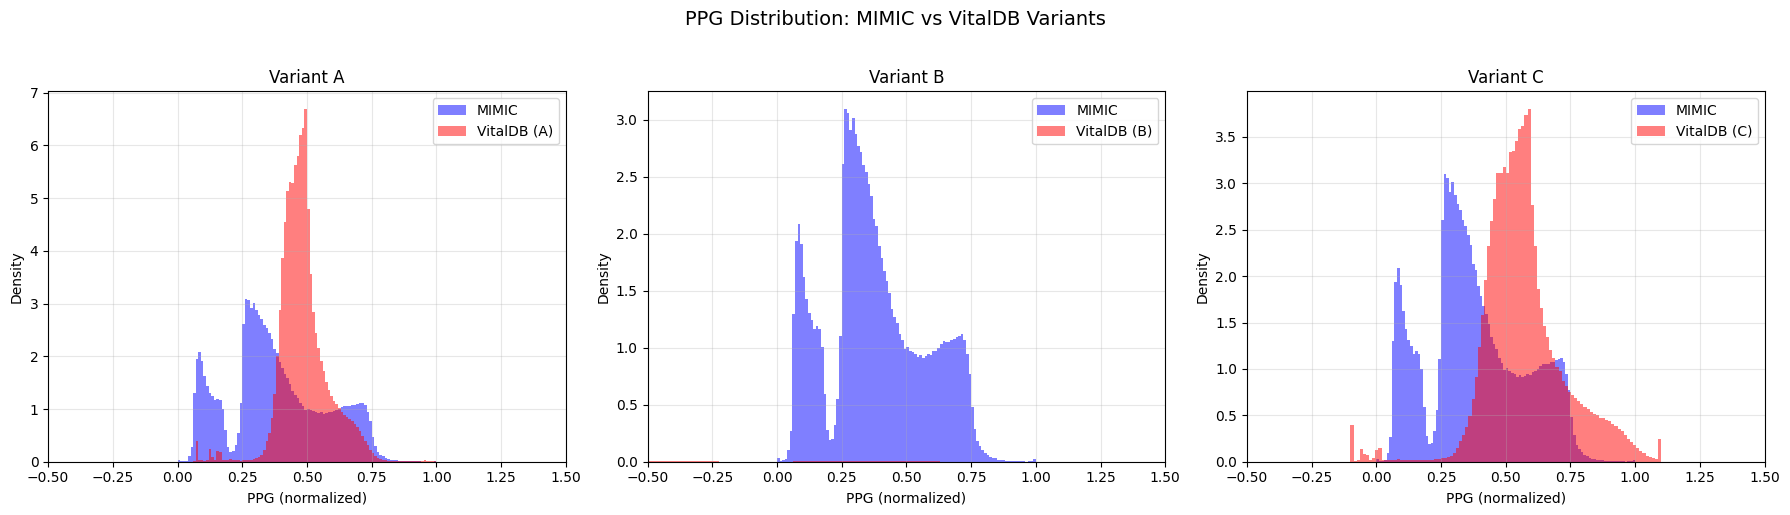

In [4]:
# Histogram: normalized PPG values
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
X_mimic_flat = X_mimic.flatten()

for i, (name, X_norm) in enumerate(variants.items()):
    ax = axes[i]
    ax.hist(X_mimic_flat, bins=100, alpha=0.5, label='MIMIC', density=True, color='blue')
    ax.hist(X_norm.flatten(), bins=100, alpha=0.5, label=f'VitalDB ({name})', density=True, color='red')
    ax.set_title(f'Variant {name}')
    ax.set_xlabel('PPG (normalized)')
    ax.set_ylabel('Density')
    ax.legend()
    ax.set_xlim(-0.5, 1.5)
    ax.grid(True, alpha=0.3)

plt.suptitle('PPG Distribution: MIMIC vs VitalDB Variants', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

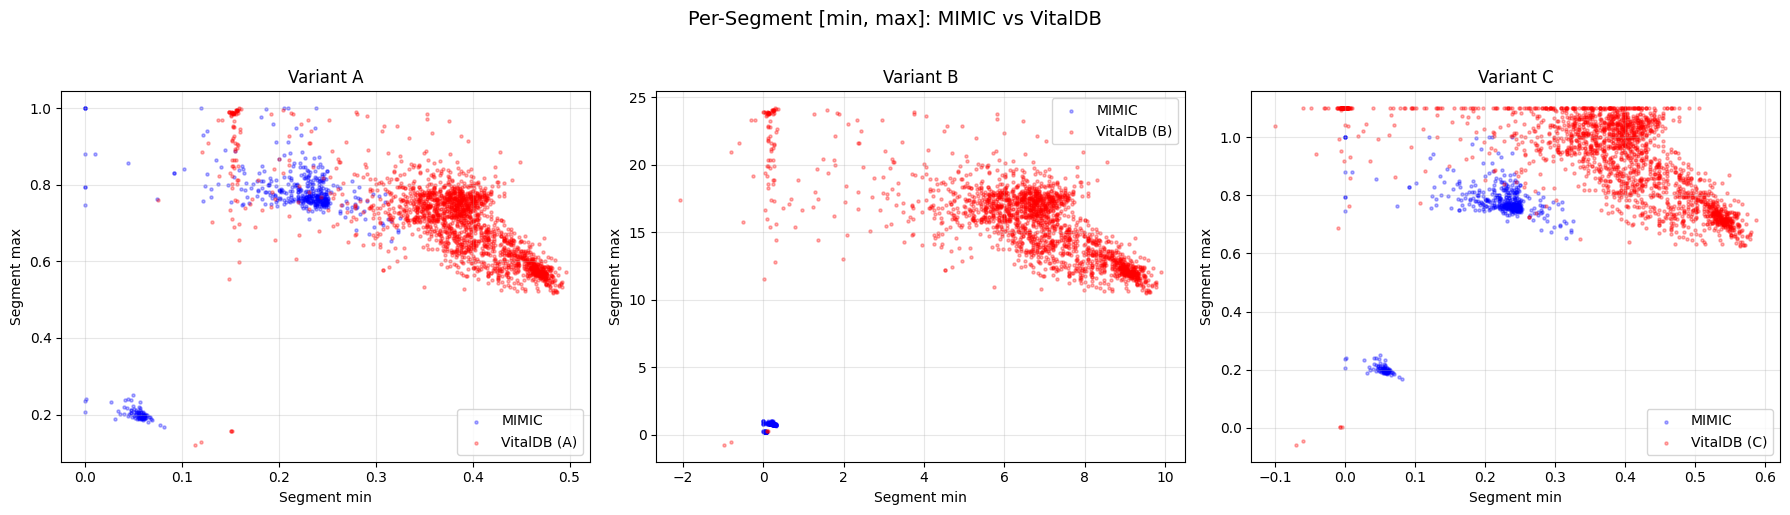

In [5]:
# Per-segment [min, max] scatter plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
mimic_seg_min = X_mimic.min(axis=1).flatten()
mimic_seg_max = X_mimic.max(axis=1).flatten()

for i, (name, X_norm) in enumerate(variants.items()):
    ax = axes[i]
    X_2d = X_norm.reshape(-1, SEGMENT_LENGTH)
    seg_min = X_2d.min(axis=1)
    seg_max = X_2d.max(axis=1)
    ax.scatter(mimic_seg_min[:2000], mimic_seg_max[:2000],
               alpha=0.3, s=5, label='MIMIC', color='blue')
    ax.scatter(seg_min[:2000], seg_max[:2000],
               alpha=0.3, s=5, label=f'VitalDB ({name})', color='red')
    ax.set_xlabel('Segment min')
    ax.set_ylabel('Segment max')
    ax.set_title(f'Variant {name}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Per-Segment [min, max]: MIMIC vs VitalDB', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

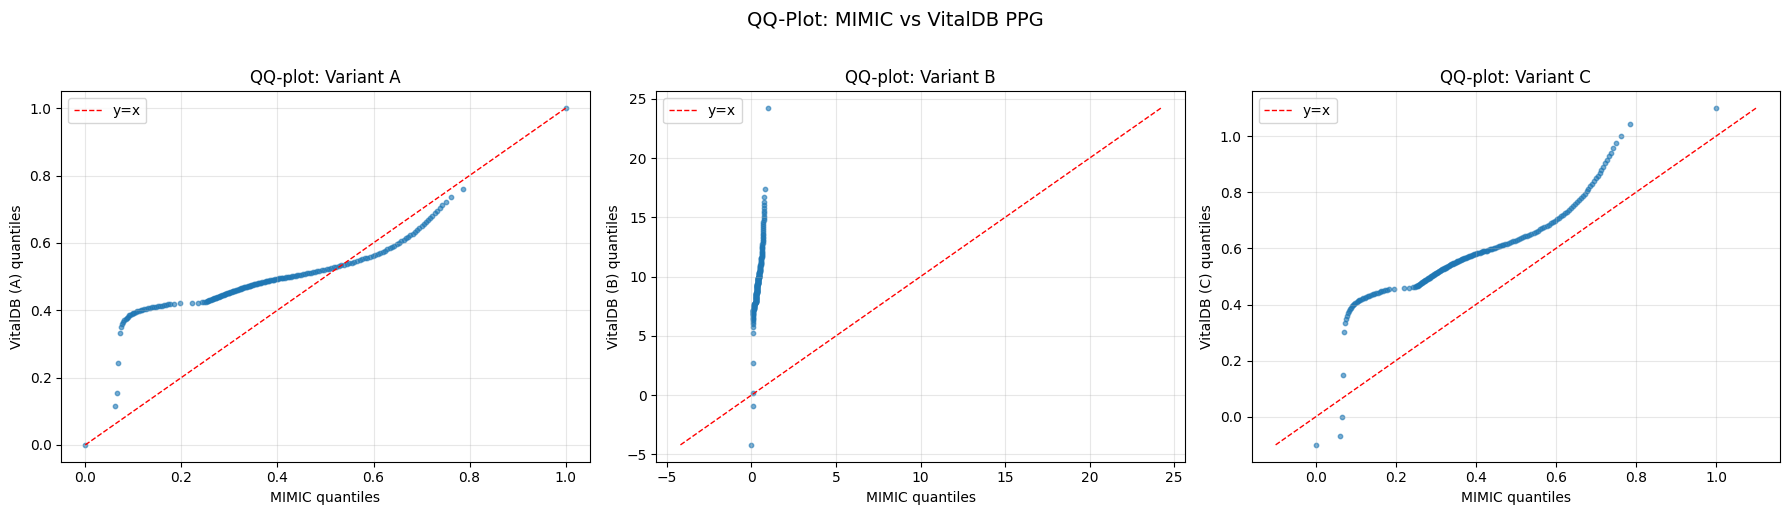

In [6]:
# QQ-plot: quantiles VitalDB vs MIMIC
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
quantiles = np.linspace(0, 100, 200)
mimic_q = np.percentile(X_mimic_flat, quantiles)

for i, (name, X_norm) in enumerate(variants.items()):
    ax = axes[i]
    vital_q = np.percentile(X_norm.flatten(), quantiles)
    ax.scatter(mimic_q, vital_q, s=10, alpha=0.6)
    lim_min = min(mimic_q.min(), vital_q.min(), 0)
    lim_max = max(mimic_q.max(), vital_q.max(), 1)
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1, label='y=x')
    ax.set_xlabel('MIMIC quantiles')
    ax.set_ylabel(f'VitalDB ({name}) quantiles')
    ax.set_title(f'QQ-plot: Variant {name}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('QQ-Plot: MIMIC vs VitalDB PPG', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Inference

In [7]:
import torch
from _models_pytorch import UNetDS64, MultiResUNet1D

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

approx_model = UNetDS64(in_channels=1, out_channels=1).to(device)
approx_model.load_state_dict(
    torch.load('models/approximate_state_dict.pth', map_location=device, weights_only=True))
approx_model.eval()

refine_model = MultiResUNet1D(n_channel=1).to(device)
refine_model.load_state_dict(
    torch.load('models/refinement_state_dict.pth', map_location=device, weights_only=True))
refine_model.eval()

print("Models loaded.")


def run_inference(X_norm_2d, batch_size=BATCH_SIZE):
    """ApproxNet → RefineNet → denormalize to mmHg.

    Args:
        X_norm_2d: (N, 1024) normalized PPG
    Returns:
        (N, 1024) predicted ABP in mmHg
    """
    X = torch.tensor(
        X_norm_2d.reshape(-1, SEGMENT_LENGTH, 1),
        dtype=torch.float32)
    N = len(X)
    preds = []

    for start in range(0, N, batch_size):
        batch = X[start:start + batch_size].to(device)
        with torch.no_grad():
            approx_out = approx_model(batch)
            y = approx_out[0].permute(0, 2, 1).contiguous()
            refined = refine_model(y)
            refined = refined.permute(0, 2, 1).contiguous()  # (B, 1024, 1)
        pred_batch = refined.cpu().numpy() * (max_abp - min_abp) + min_abp
        preds.append(pred_batch[:, :, 0])

    return np.concatenate(preds, axis=0)

Device: cuda
Models loaded.


In [8]:
predictions = {}
for name, X_norm in variants.items():
    print(f"Variant {name}: inference on {len(X_norm)} segments...", end=' ')
    predictions[name] = run_inference(X_norm)
    print(f"done. pred range: [{predictions[name].min():.1f}, {predictions[name].max():.1f}] mmHg")

Variant A: inference on 9400 segments... done. pred range: [-620.5, 23031.4] mmHg
Variant B: inference on 9400 segments... done. pred range: [-11026.2, 721884.4] mmHg
Variant C: inference on 9400 segments... done. pred range: [-12074.9, 6815.2] mmHg


## 5. Metrics

In [9]:
def compute_metrics(pred_mmhg, Y_gt, abp_filter=None):
    """Compute waveform MAE, SBP/DBP/MAP errors, BHS grading.

    Args:
        pred_mmhg: (N, 1024) predicted ABP in mmHg
        Y_gt: (N, 1024) ground truth ABP in mmHg
        abp_filter: optional (min, max) to filter segments by GT ABP range
    """
    if abp_filter is not None:
        seg_dbp = Y_gt.min(axis=1)
        seg_sbp = Y_gt.max(axis=1)
        mask = (seg_dbp >= abp_filter[0]) & (seg_sbp <= abp_filter[1])
        pred_mmhg = pred_mmhg[mask]
        Y_gt = Y_gt[mask]

    N = len(pred_mmhg)

    # Waveform MAE
    mae_per_seg = np.mean(np.abs(pred_mmhg - Y_gt), axis=1)

    # SBP / DBP / MAP errors
    sbp_err = np.abs(pred_mmhg.max(axis=1) - Y_gt.max(axis=1))
    dbp_err = np.abs(pred_mmhg.min(axis=1) - Y_gt.min(axis=1))
    map_err = np.abs(pred_mmhg.mean(axis=1) - Y_gt.mean(axis=1))

    # BHS grading
    def bhs(err):
        return ((err <= 5).mean() * 100,
                (err <= 10).mean() * 100,
                (err <= 15).mean() * 100)

    def bhs_grade(pct5, pct10, pct15):
        if pct5 >= 60 and pct10 >= 85 and pct15 >= 95:
            return 'A'
        elif pct5 >= 50 and pct10 >= 75 and pct15 >= 90:
            return 'B'
        elif pct5 >= 40 and pct10 >= 65 and pct15 >= 85:
            return 'C'
        else:
            return 'D'

    sbp_bhs = bhs(sbp_err)
    dbp_bhs = bhs(dbp_err)
    map_bhs = bhs(map_err)

    return {
        'n': N,
        'mae': (mae_per_seg.mean(), mae_per_seg.std()),
        'sbp': (sbp_err.mean(), sbp_err.std()),
        'dbp': (dbp_err.mean(), dbp_err.std()),
        'map': (map_err.mean(), map_err.std()),
        'sbp_bhs': sbp_bhs, 'dbp_bhs': dbp_bhs, 'map_bhs': map_bhs,
        'sbp_grade': bhs_grade(*sbp_bhs),
        'dbp_grade': bhs_grade(*dbp_bhs),
        'map_grade': bhs_grade(*map_bhs),
    }

In [10]:
# Compute metrics for all variants: (a) all segments, (b) ABP ∈ [50, 200]
results_all = {}
results_filt = {}

for name in variants:
    results_all[name] = compute_metrics(predictions[name], Y_raw)
    results_filt[name] = compute_metrics(predictions[name], Y_raw, abp_filter=(50, 200))


def fmt(mean_std):
    return f"{mean_std[0]:.2f} \u00b1 {mean_std[1]:.2f}"


# Comparison table
rows = []
for name in ['A', 'B', 'C']:
    r = results_all[name]
    rf = results_filt[name]
    rows.append({
        'Variant': name,
        'N (all)': r['n'],
        'MAE all': fmt(r['mae']),
        'SBP err': fmt(r['sbp']),
        'DBP err': fmt(r['dbp']),
        'MAP err': fmt(r['map']),
        'N [50-200]': rf['n'],
        'MAE [50-200]': fmt(rf['mae']),
        'SBP grade': rf['sbp_grade'],
        'DBP grade': rf['dbp_grade'],
        'MAP grade': rf['map_grade'],
    })

df = pd.DataFrame(rows)
print("=" * 100)
print("ABLATION: NORMALIZATION VARIANTS")
print("=" * 100)
print(df.to_string(index=False))

ABLATION: NORMALIZATION VARIANTS
Variant  N (all)        MAE all           SBP err        DBP err        MAP err  N [50-200]   MAE [50-200] SBP grade DBP grade MAP grade
      A     9400  25.92 ± 16.60    52.97 ± 562.64  12.32 ± 21.46  15.13 ± 16.93        7129  23.29 ± 12.86         D         D         D
      B     9400 81.35 ± 216.17 471.14 ± 11776.15 36.72 ± 247.57 78.26 ± 210.68        7129 77.07 ± 222.09         D         D         D
      C     9400  29.10 ± 78.61    34.18 ± 179.46 27.00 ± 342.81  17.93 ± 74.99        7129  26.91 ± 84.83         D         D         D


In [11]:
# BHS detail for Variant C on ABP ∈ [50, 200]
print("BHS Detail — Variant C (ABP ∈ [50, 200])")
print("-" * 55)
print(f"{'':>4} {'≤5 mmHg':>10} {'≤10 mmHg':>10} {'≤15 mmHg':>10} {'Grade':>8}")
print("-" * 55)
rc = results_filt['C']
for key in ['sbp', 'dbp', 'map']:
    bhs = rc[f'{key}_bhs']
    grade = rc[f'{key}_grade']
    print(f"{key.upper():>4} {bhs[0]:>9.1f}% {bhs[1]:>9.1f}% {bhs[2]:>9.1f}% {grade:>8}")
print("-" * 55)
print(f"\nWaveform MAE: {fmt(rc['mae'])} mmHg")
print(f"SBP error:    {fmt(rc['sbp'])} mmHg")
print(f"DBP error:    {fmt(rc['dbp'])} mmHg")
print(f"MAP error:    {fmt(rc['map'])} mmHg")

BHS Detail — Variant C (ABP ∈ [50, 200])
-------------------------------------------------------
        ≤5 mmHg   ≤10 mmHg   ≤15 mmHg    Grade
-------------------------------------------------------
 SBP      13.7%      26.9%      39.7%        D
 DBP      38.9%      68.0%      84.2%        D
 MAP      27.8%      53.7%      72.6%        D
-------------------------------------------------------

Waveform MAE: 26.91 ± 84.83 mmHg
SBP error:    30.20 ± 197.71 mmHg
DBP error:    25.87 ± 362.48 mmHg
MAP error:    14.56 ± 80.56 mmHg


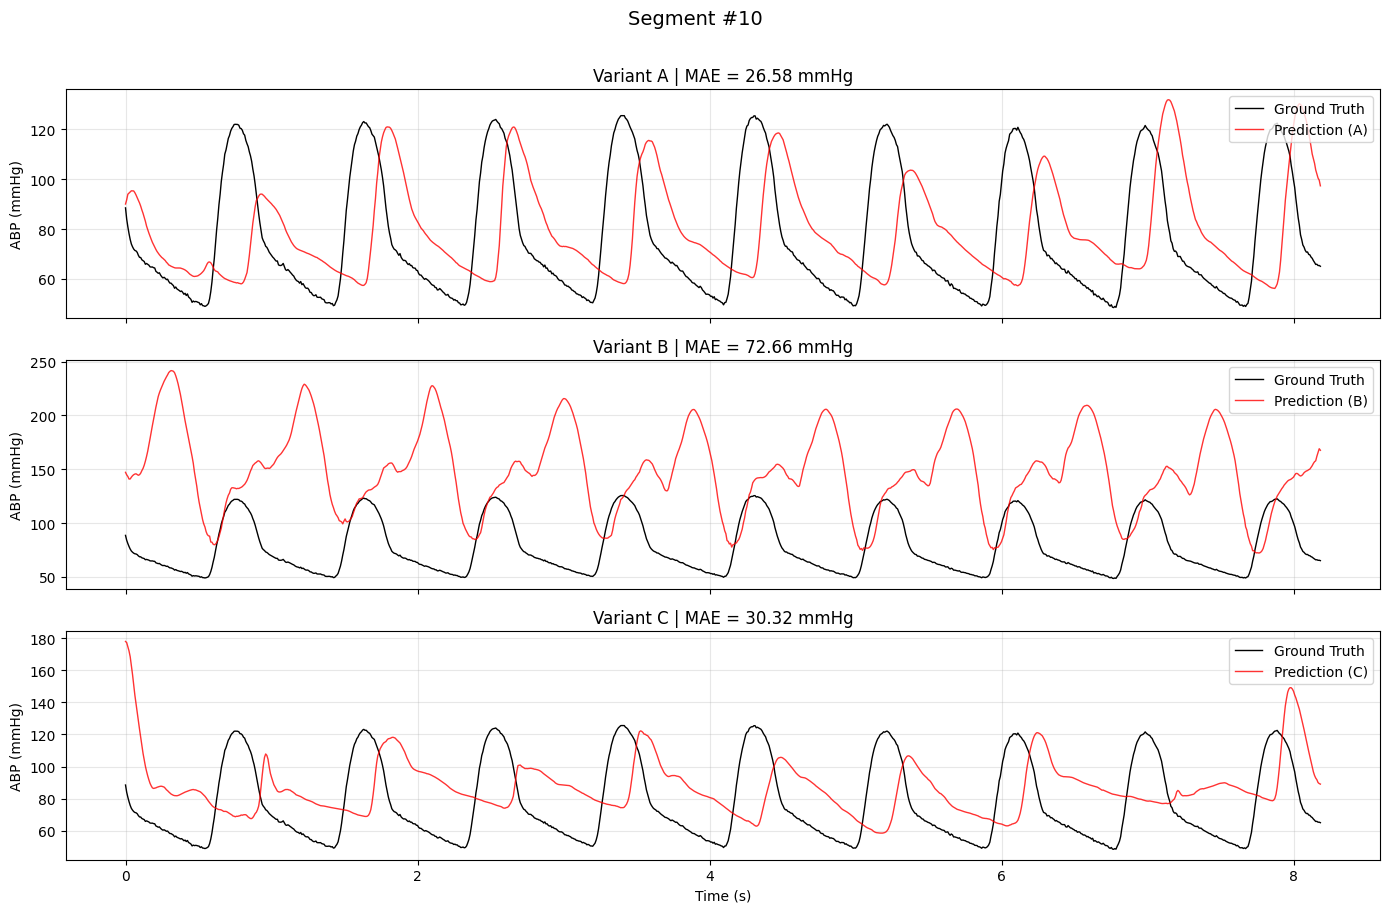

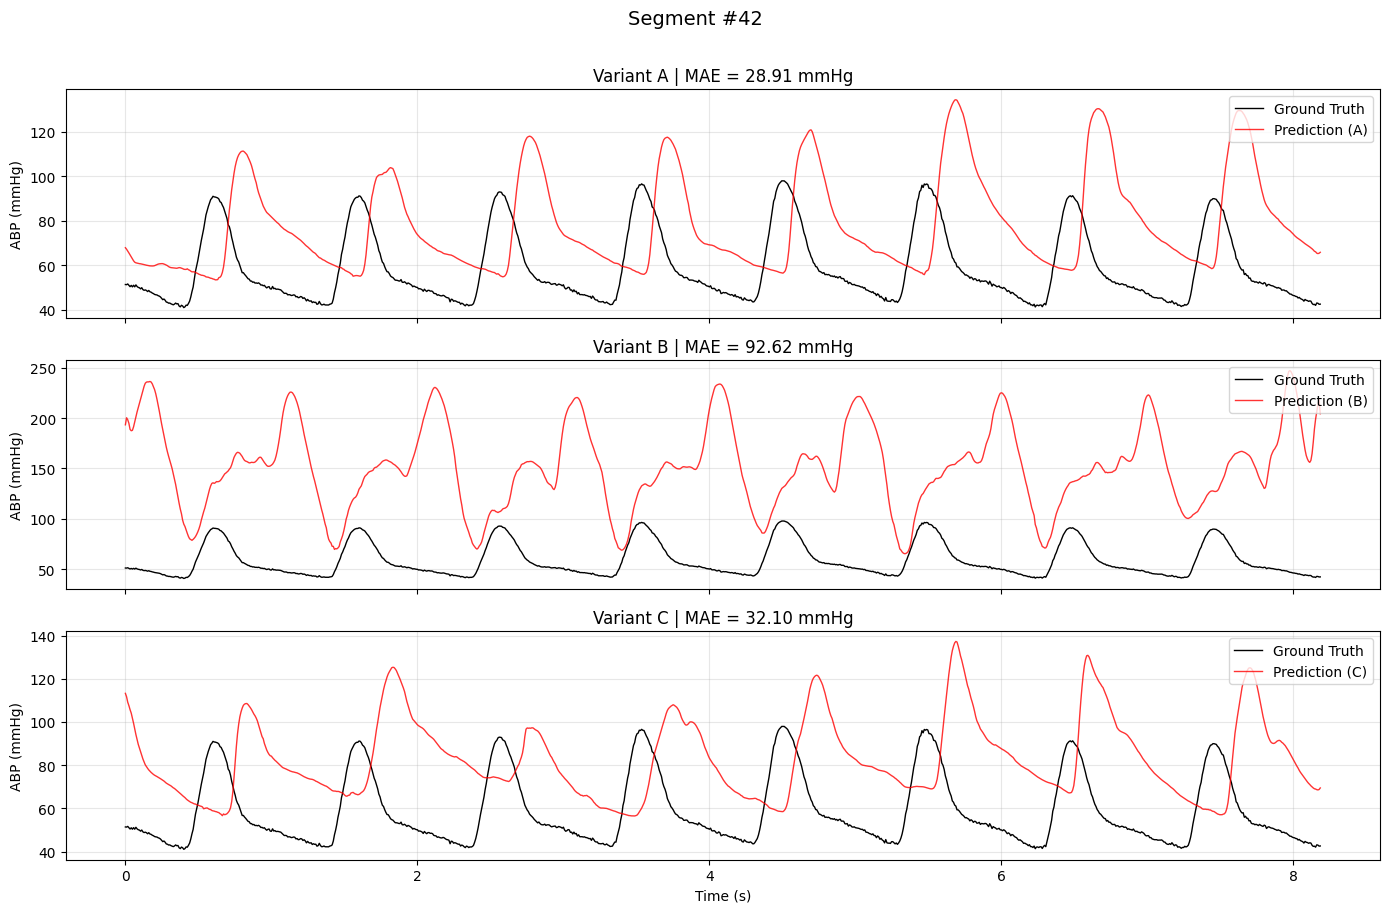

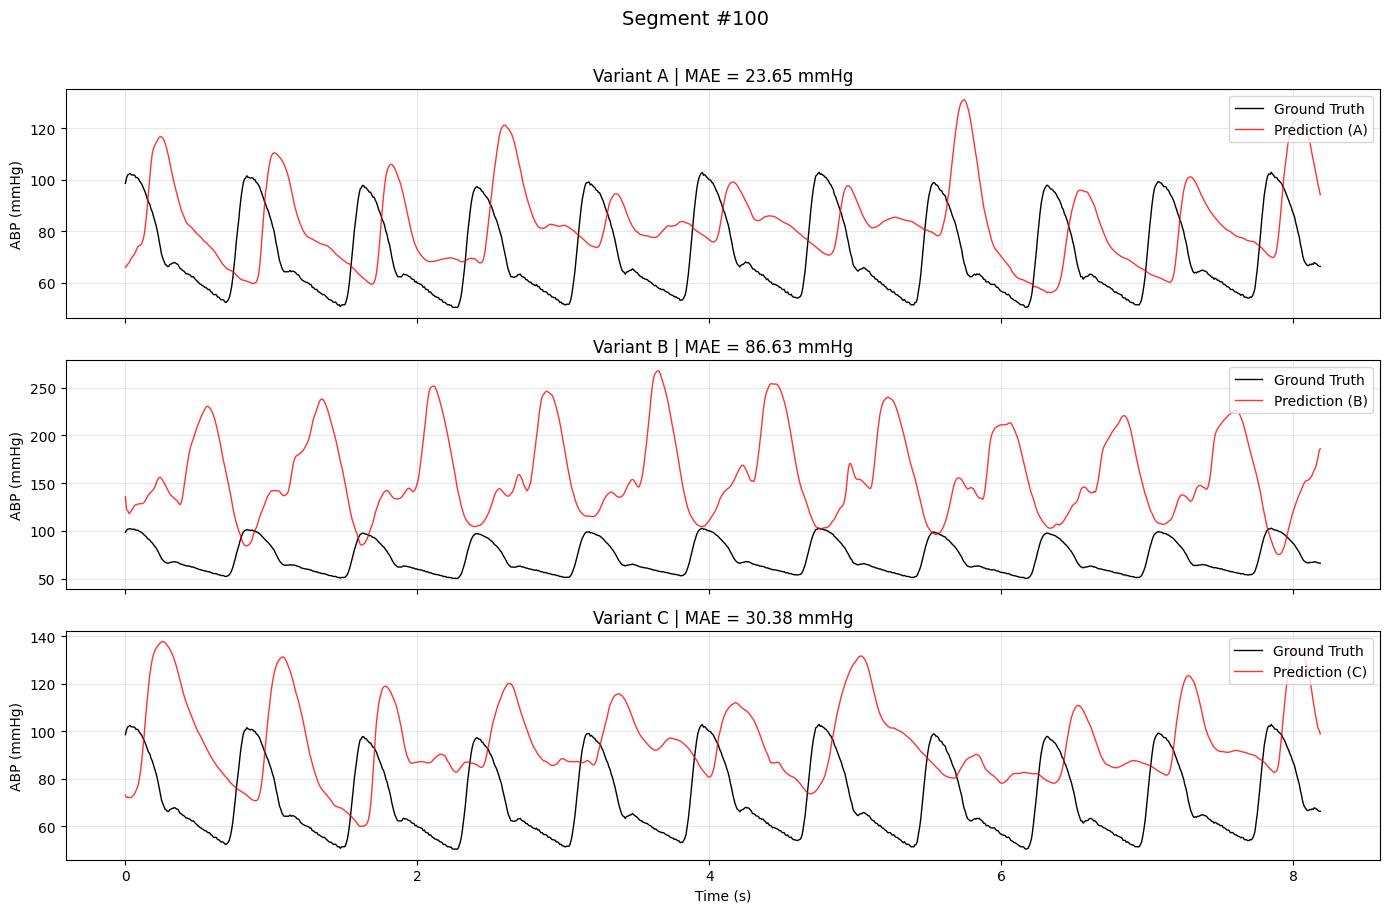

In [12]:
# Waveform examples: compare all 3 variants on same segment
t = np.arange(SEGMENT_LENGTH) / FS

for sample_idx in [10, 42, 100]:
    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    for i, name in enumerate(['A', 'B', 'C']):
        ax = axes[i]
        ax.plot(t, Y_raw[sample_idx], 'k-', label='Ground Truth', linewidth=1)
        ax.plot(t, predictions[name][sample_idx], 'r-',
                label=f'Prediction ({name})', linewidth=1, alpha=0.8)
        mae = np.mean(np.abs(predictions[name][sample_idx] - Y_raw[sample_idx]))
        ax.set_title(f'Variant {name} | MAE = {mae:.2f} mmHg')
        ax.set_ylabel('ABP (mmHg)')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel('Time (s)')
    plt.suptitle(f'Segment #{sample_idx}', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

## 6. Save Best Variant

Save Variant C (percentile alignment) as `data/vitaldb_test.p` in standard format.

In [13]:
P1 = float(np.percentile(X_raw, 1))
P99 = float(np.percentile(X_raw, 99))
a_coeff = float((max_ppg - min_ppg) / (P99 - P1))
b_coeff = float(min_ppg - a_coeff * P1)

X_norm_c = variants['C'].reshape(-1, SEGMENT_LENGTH, 1)
Y_test = Y_raw.reshape(-1, SEGMENT_LENGTH, 1).astype(np.float32)

vitaldb_data = {
    'X_test': X_norm_c,       # PPG normalized via percentile alignment
    'Y_test': Y_test,         # ABP in mmHg
    'source': 'VitalDB',
    'fs': FS,
    'segment_length': SEGMENT_LENGTH,
    'n_segments': len(X_norm_c),
    'normalization': 'percentile_alignment',
    'normalization_params': {
        'method': 'percentile_linear_alignment',
        'P1': P1, 'P99': P99,
        'a': a_coeff, 'b': b_coeff,
        'clip_range': [-0.1, 1.1],
        'meta_file': 'meta9.p',
    },
}

output_path = os.path.join('data', 'vitaldb_test.p')
with open(output_path, 'wb') as f:
    pickle.dump(vitaldb_data, f)

print(f"Saved to {output_path}")
print(f"  X_test: {X_norm_c.shape} (PPG, percentile-aligned, clipped [-0.1, 1.1])")
print(f"  Y_test: {Y_test.shape} (ABP, mmHg)")
print(f"  Normalization: a={a_coeff:.5f}, b={b_coeff:.5f}")
print(f"  P1={P1:.3f}, P99={P99:.3f}")

Saved to data\vitaldb_test.p
  X_test: (9400, 1024, 1) (PPG, percentile-aligned, clipped [-0.1, 1.1])
  Y_test: (9400, 1024, 1) (ABP, mmHg)
  Normalization: a=0.06051, b=-0.04925
  P1=0.814, P99=66.956
